<a href="https://colab.research.google.com/github/smrutisahu2226/Smruti_SynapseTask2026/blob/main/Copy_of_week1_ML_Task1A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Synapse Week One**

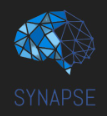

Last week, we focused on building the foundations needed to get started with Machine Learning. We explored Python and learned how to work with and understand data through Exploratory Data Analysis (EDA).

Now, it is time to take the next step and use that knowledge to build our first Machine Learning model. In this task, we will explore Regression, a type of supervised learning where the goal is to predict a continuous numerical value.

We will begin by exploring an insurance dataset and using EDA to understand the relationships between its different attributes and the insurance charges. Once we understand our data, we will prepare it for Machine Learning and build a Linear Regression model to predict the incurred charges.

But we won't stop at simply using a library. We will also take a look under the hood and implement Linear Regression from scratch, giving us a better understanding of what happens when a model is trained.

Resources and comments are provided throughout the notebook. Go through them carefully, understand the concepts, and then get coding.

Let's get started.

Supervised vs Unsupervised vs Reinforcement Learning:

https://www.simplilearn.com/tutorials/machine-learning-tutorial/types-of-machine-learning

Regression vs Classification :

https://www.analyticsvidhya.com/blog/2023/05/regression-vs-classification/ (Might be a little wordy)

https://www.youtube.com/watch?v=1NBwM5tavTk&ab_channel=IntuitiveML
(A very quick video)

https://www.geeksforgeeks.org/ml-classification-vs-regression/
(Short and Sweet)

Machine Learning for Everyone (Read till 1.1):

https://vas3k.com/blog/machine_learning/

Overfitting and Underfitting [VERY IMPORTANT]
https://www.youtube.com/watch?v=T9NtOa-IITo

Lets import all the basic libraries.

In [ ]:
!pip install shap -q  #Will be used later on

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# Regression

For regression we will use insurance dataset, which contains medical costs incurred
https://drive.google.com/file/d/1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ/view?usp=sharing

## Basic EDA

In [ ]:
#df=pd.read_csv("C:\Users\Smrutirani\Downloads\insurance.csv")
!wget -O insurance.csv "https://docs.google.com/uc?export=download&id=1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ"
df=pd.read_csv("insurance.csv")

--2026-10-02 10:21:36--  https://docs.google.com/uc?export=download&id=1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ
Resolving docs.google.com (docs.google.com)... 142.251.121.138, 142.251.121.100, 142.251.121.139, ...
Connecting to docs.google.com (docs.google.com)|142.251.121.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ&export=download [following]
--2026-10-02 10:21:36--  https://drive.usercontent.google.com/download?id=1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.121.132, 2607:f8b0:4023:80b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.121.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55628 (54K) [application/octet-stream]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  54.32K  --.-KB/s   

In [ ]:
df.shape

(1338, 7)

### Use the very first steps involved in EDA -> info, head and describe

In [ ]:
df.head(20)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Now, plot a histogram to understand insurance charges *distribution*

<Axes: xlabel='charges', ylabel='Count'>

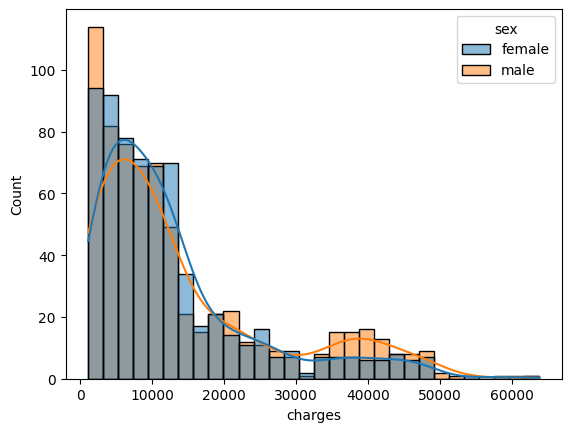

In [ ]:
sb.histplot(data=df,x='charges',hue='sex',kde=True)

### Plot a scatter plot between age and insurance charges

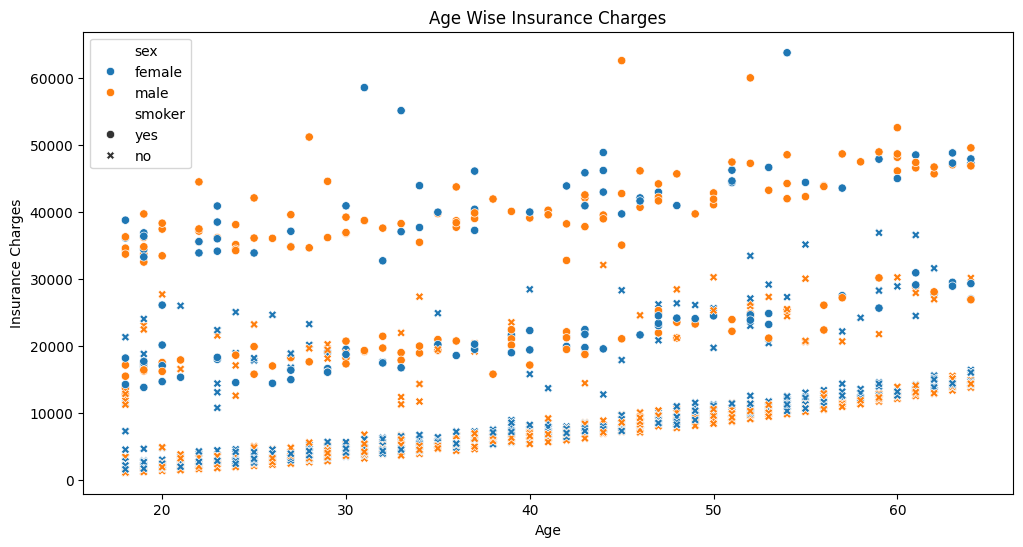

In [ ]:
# plt.scatter(x = df['age'] , y = df['charges'],s=5,alpha=0.9)

plt.figure(figsize=(12,6))

# Column Name are case sensitive
sb.scatterplot( data = df , x = 'age' , y = 'charges' , hue = 'sex' , style = 'smoker')

plt.xlabel("Age")
plt.ylabel('Insurance Charges')
plt.title('Age Wise Insurance Charges')

plt.show() # If this line written then this will not come --> Text(0.5, 1.0, 'Age Wise Insurance Charges')

### Similarly, plot scatterplots for no. of children and charges, and also for bmi and charges


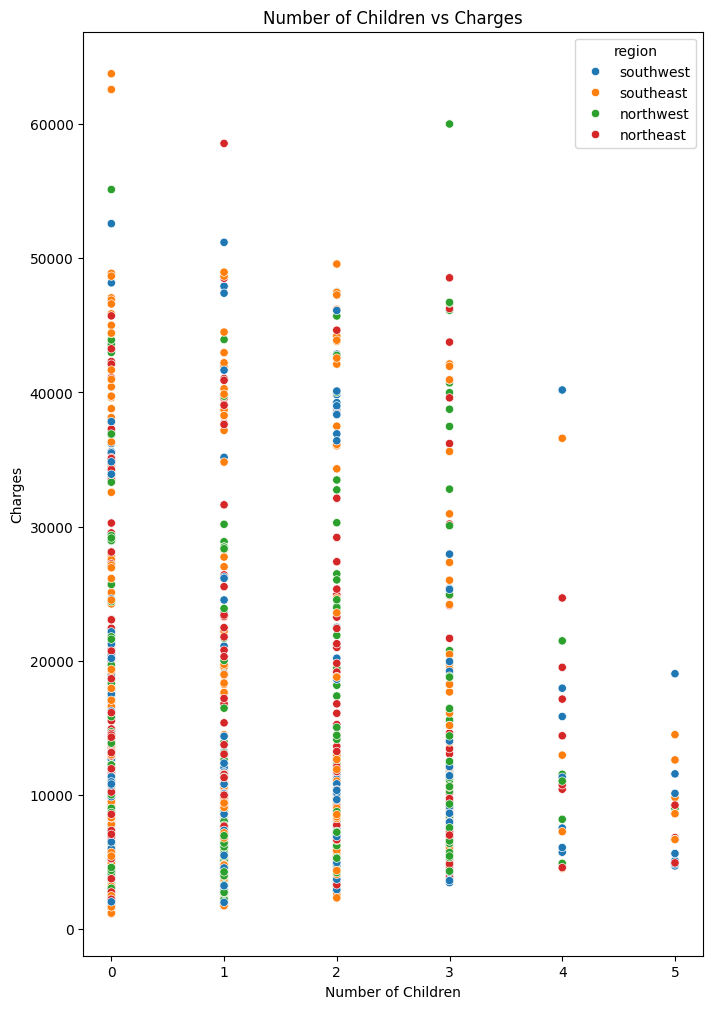

In [ ]:
plt.figure(figsize = (8,12))

sb.scatterplot(data = df,x="children",y='charges',hue="region")

plt.xlabel("Number of Children")
plt.ylabel("Charges")
plt.title("Number of Children vs Charges")
plt.show()

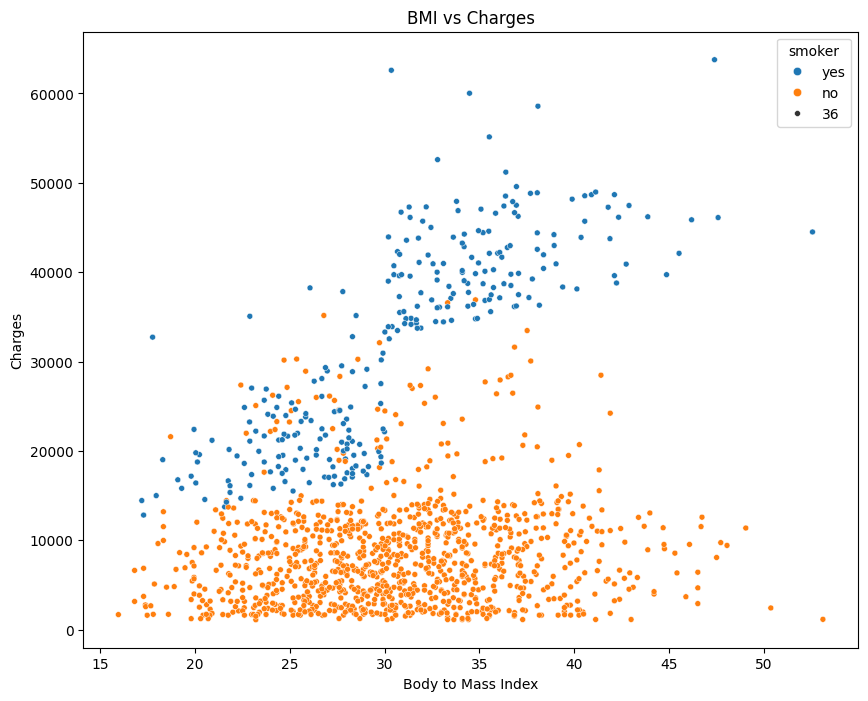

In [ ]:
plt.figure(figsize = (10,8))

sb.scatterplot(data = df , x = 'bmi' , y = 'charges', size = 36 , alpha=1 , hue = 'smoker')

plt.xlabel('Body to Mass Index')
plt.ylabel('Charges')
plt.title("BMI vs Charges")
plt.show()

### Now, use boxplots to find correlation between Sex and Charges, between Smoker and charges, and also between region and charges

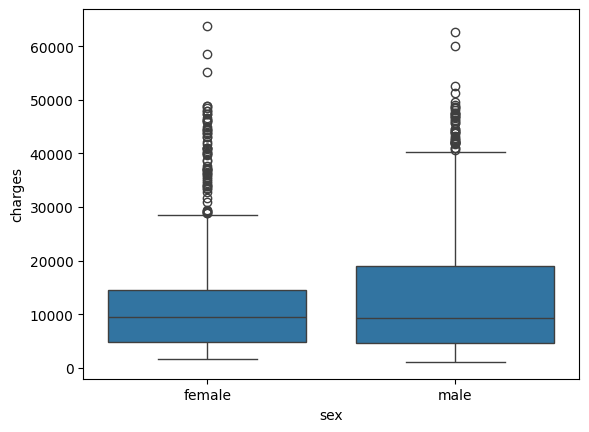

1.5158796580240388


In [ ]:
sb.boxplot(data=df,x='sex',y='charges')
plt.show()
print(df['charges'].skew())

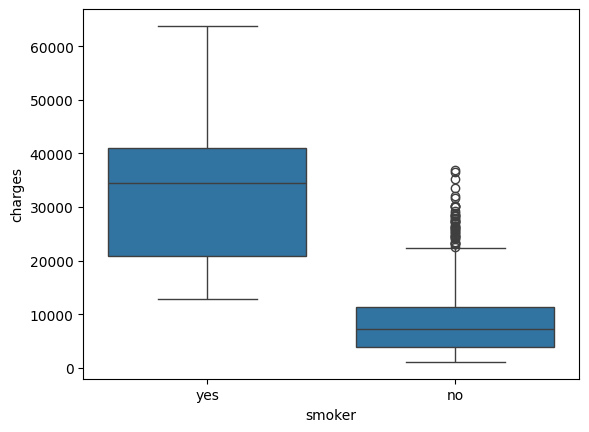

In [ ]:
sb.boxplot(data=df,y='charges',x='smoker')
plt.show()

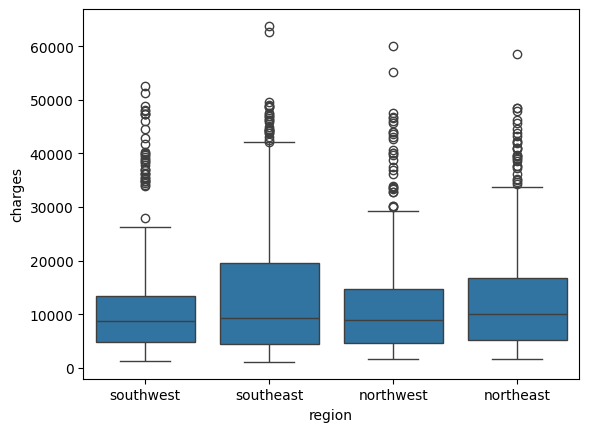

In [ ]:
sb.boxplot(data=df,x='region',y='charges')
plt.show()

##### Now, make a heatmap to understand correlation between all attributes

<Axes: >

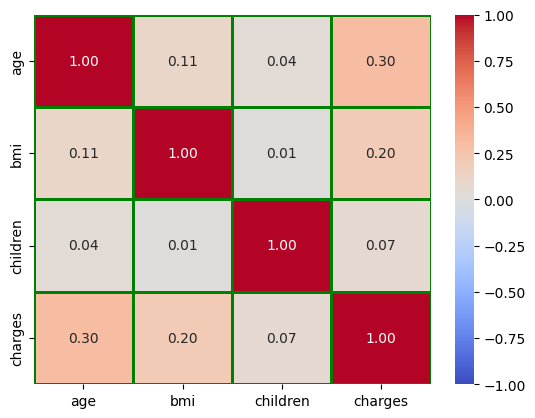

In [ ]:
sb.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap='coolwarm',linewidths=1,linecolor="green",vmax=1,vmin=-1,center=0)

## Question: What do you infer from the above analysis🤔

### Answer here:
1. Histogram : The distrubution is right-skewed as we can see a long tail towards right,hence for this distribution mean>median. Most of the charges are between 0 to 15000 and they decrease significantly as we move towards higher charges. For both male and female distribution is right skewed.Females have high frequency for low charges while men have high frequeny for high charges.

2. Scatter Plot :
  (A) As Insurance charges increase age increases for smokers and non-smokers , and thus there is a positive association between these age and Insurance charges. For all age groups , smokers have higher charges as compared to non-smokers. Age is not the only feature to decide charges as smokers also affect the distribution.However, gender of the person is not affecting the charges at a good level.   
  (B) This is a discrete distribution. There is no clear relationship between number of children and region with Insurance charges.As there is overplotting for discrete values a box plot migjt be much better than scatter plot.
  (C) BMI shows a positive association with insurance charges, particularly among smokers. Among non-smokers, the relationship appears much weaker and more scattered., BMI alone does not explain the variation in charges, while smoking status appears to be an important variable associated with the charges.

3. Box Plot :
  (A) The median charges for males and females are approximately similar.The median charges for males and females are approximately similar.The upper whisker is much longer than the lower whisker for both groups.Both female and male charge distributions appear to be right-skewed (positively skewed).Both groups contain extreme high-charge observations.
  (B) Medical charges are substantially higher for smokers than non-smokers, with the smoker group having a much higher median and a considerably larger IQR. The charges for smokers also extend to much higher values. The non-smoker distribution is strongly right-skewed and contains numerous high-value outliers. Overall, smoking status is associated with a substantial difference in the observed distribution of medical charges in this dataset.
  (C) All four regional charge distributions appear positively/right-skewed, with substantially longer upper tails and many high-value observations.The non-outlier charges extend to a considerably higher level in the southeast region.The southeast region has the greatest spread in the middle 50% of charges, while southwest has the smallest IQR.

4. Heatmap : The heatmap shows that all variables have positive correlations with each other, but most relationships are weak. Age has the strongest correlation with charges at 0.30, followed by BMI with charges at 0.20. Age and BMI have a very weak correlation of 0.11, while the relationships involving children are almost negligible, with correlations ranging from 0.01 to 0.07. Overall, there are no strong linear correlations among these variables.

### Now let's prep our data to perform Regression to predict the Incurred Charges

### Again do df.info() see how the datatype is

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### As you can see, sex, region and smoker attributes are of the object data type.
### So, convert them into numerical labels, using Label Encoder

In [ ]:
from sklearn.preprocessing import *

In [ ]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['region'] = le.fit_transform(df['region'])
df['smoker'] = le.fit_transform(df['smoker'])

Do df.head() to see how your dataframe looks like after LabelEncoding

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Question: What does label encoder do? 🤔

LabelEncoder converts categorical text values into numbers so machine learning models can process them. For example, in a column with 'Male' and 'Female', it might convert Male =0 and Female =1.

### Now that you already know about standardization and normalization (I hope🙃), implement normalization here here:


##### Import MinMaxScaler from sklearn and normalize the coloums - ['age','bmi', 'children', 'charges']

In [ ]:
df[['age','bmi', 'children', 'charges']] = MinMaxScaler().fit_transform(df[['age','bmi', 'children', 'charges']])

In [ ]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,0.461022,0.505232,0.395572,0.218984,0.204783,1.515695,0.193916
std,0.305434,0.500160,0.164062,0.241099,0.403694,1.104885,0.193301
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.195652,0.000000,0.278080,0.000000,0.000000,1.000000,0.057757
50%,0.456522,1.000000,0.388485,0.200000,0.000000,2.000000,0.131849
75%,0.717391,1.000000,0.504002,0.400000,0.000000,2.000000,0.247700
max,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000




### Answer:

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,0.021739,0,0.321227,0.0,1,3,0.251611
1,0.000000,1,0.479150,0.2,0,2,0.009636
2,0.217391,1,0.458434,0.6,0,2,0.053115
3,0.326087,1,0.181464,0.0,0,1,0.333010
4,0.304348,1,0.347592,0.0,0,1,0.043816


## Question: Why standardization is not needed here? 🤔



Standardization can also be applied to the numerical columns such as age, BMI, children, and charges. However, in this case, we used normalization because we wanted to bring all these features to a common scale of 0 to 1. The original features have very different ranges—for example, age is around 18–64, BMI is around 15–50, children is a small count, while charges can have values in the thousands. Normalization makes their scales comparable without changing the relative pattern of the data. Standardization would also be valid, but it would convert the values based on their mean and standard deviation, giving them a mean of 0 and standard deviation of 1. Since there was no specific requirement or need for that representation here, normalization was sufficient.

### Answer:

### Train-Test Split

Implementation - https://www.youtube.com/watch?v=BUkqYGPnLZ8&ab_channel=ManifoldAILearning

### Now, while we need data to train our regression model, it is equally important to keep some data aside for testing the effectiveness of the aforementioned model. Thus the dataset as a whole is generally further divided into the training dataset and the testing dataset.

In order to implement this, import train_test_split function from scikit-learn.

In [ ]:
from sklearn.model_selection import train_test_split

Print the size and shape of each of the train/test splits (it should be in the ratio as per test_size parameter above, i.e in ratio of 0.3)

In [ ]:
X = df[['age','sex','bmi','children','smoker','region']]
y = df[['charges']]
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=1,shuffle=True)

In [ ]:
print(f"Shape of X_train = {X_train.shape} , X_test = {X_test.shape} , y_train = {y_train.shape} , y_test = {y_test.shape} ")

Shape of X_train = (936, 6) , X_test = (402, 6) , y_train = (936, 1) , y_test = (402, 1) 


### The data is now split into 2 datasets of size 70% and 30% of original dataset. Surprised? 😮

### We have preprocessed our DataFrame now we'll perform Regression on this Data

### First lets understand Linear Regression, watch this video carefully it will be helpfull later on :)

https://www.youtube.com/watch?v=7ArmBVF2dCs

### A quick article
https://www.analyticsvidhya.com/blog/2021/08/understanding-linear-regression-with-mathematical-insights/

In [ ]:
#train a model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
# fit the model on the training data, hint: use the fit method
model.fit(X_train,y_train)

LinearRegression()

#### The X_train and y_train dataframes have been used to train the model. Now we will use X_test and y_test to evaluate the efficiency of the model we have trained.

#### Use regressor.predict() on X_test and store it in a variable called "y_pred". Print type and size of the y_pred.

#### Size should be 402 if everything is correct. Yeh line confirm karna hai

In [ ]:
# make predictions on the test data
y_pred = model.predict(X_test)

In [ ]:
print(type(y_pred))
print(y_pred.shape)

<class 'numpy.ndarray'>
(402, 1)


### Visualize the predictions, plot a scatter plot of y_test vs y_pred and also plot the best fit line

In [ ]:
type(y_test)

pandas.core.frame.DataFrame

In [ ]:
type(y_pred)

numpy.ndarray

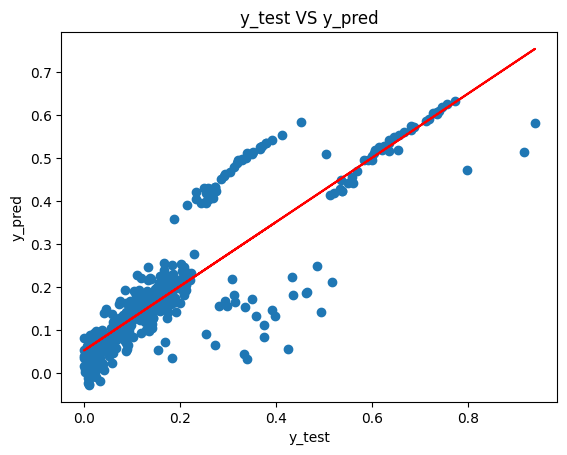

In [ ]:
# Method 1
plt.scatter(y_test,y_pred)
a = np.array(y_test.values.ravel())
b = y_pred.ravel()
m,c = np.polyfit(a,b,1)
b_line = m * a + c
plt.plot(a,b_line,color='red')

# # Method 2
# a = np.array(y_test.values.ravel())
# b = y_pred.ravel()
# # sb.regplot(x=a,y=b,color='red') --> whole plot same color
# sb.regplot(x=a,y=b,scatter_kws={'color':'blue'},line_kws={'color':'red'})


# plt.plot(y_test,y_pred,color='red') --> Wrong

plt.title("y_test VS y_pred")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()

# sb.scatterplot(x=y_test,y=y_pred) --> Worng

# Now let's start the fun part 😃

### Have you ever wondered what happens when you call **'regressor.fit(X_train, y_train)'** ?

### To understand what's hapenning in .fit method we will be implementing Linear Regression from scratch.

In [ ]:
class LinearRegression() :

    def __init__( self, learning_rate, iterations ) :
        # initialize the learning rate and iterations provides by the user
        self.learning_rate = learning_rate

        self.iterations = iterations

    # Function for model training
    def fit( self, X, Y ) :

        # no_of_training_examples, no_of_features
        self.m, self.n=X.shape

        # weight initialization

        # what does self.m and self.n represent and why are they calculated?

        # self.m represents the no. of rows (samples) in training data, while self.n shows number of features in the training data
        # they are calculated
        # weight initialization
        self.W = np.zeros(self.n)

        self.b = 0# set this equal to 0

        self.X =  X# set this equal to X

        self.Y =Y # set this equal to Y


        # gradient descent learning
        for i in range(self.iterations) : # complete the range function

            self.update_weights()

        return self

    # Helper function to update weights in gradient descent
    def update_weights(self) :

        Y_pred = self.predict(self.X) # complete this line

        # calculate gradients
        dW = -(2*(self.X.T).dot(self.Y-Y_pred))/self.m  # dL/dW -> L = MSE = (y -ypred)^2/m
        db =-2*np.sum(self.Y -Y_pred)/self.m

        # write the code to update the weights
        self.W =self.W-self.learning_rate*dW
        self.b =self.b-self.learning_rate*db

        return self


    def predict(self,X) :

        return X.dot(self.W) + self.b



## Question: What is this function actually doing? 🤔
#### Answer Here The function is predicting the value using the model which was made using gradient descent method. It calculates the weight of each feature and also adds the bias also. It is called gradient because it takes the derivative(how fast the change occurs in the MSE when we make a small change in weight) of the MSE with respect to weight and bias.  
<br>

### Now predict the output for the test data

In [ ]:
scratch_model  = LinearRegression(0.01,1000)
scratch_model.fit(X_train.values,y_train.values.ravel())

In [ ]:
scratch_model.W

array([ 0.15594883, -0.00642643,  0.08434403,  0.01716216,  0.36626585,
       -0.00572308])

In [ ]:
scratch_model.b

np.float64(0.02531591065542402)

### Calculate the mean squared error


In [ ]:
y_pred_scratch = scratch_model.predict(X_test.values)
print(y_pred_scratch.shape)   # should be (402,)

(402,)


In [ ]:
from sklearn.metrics import mean_squared_error

y_test_flat = y_test.values.ravel()

mse_sklearn = mean_squared_error(y_test_flat, y_pred.ravel())
mse_scratch = mean_squared_error(y_test_flat, y_pred_scratch)

print("sklearn MSE:", mse_sklearn)
print("scratch MSE:", mse_scratch)

sklearn MSE: 0.009374703390640669
scratch MSE: 0.010116290540033468


### Plot a similar scatter plot as above


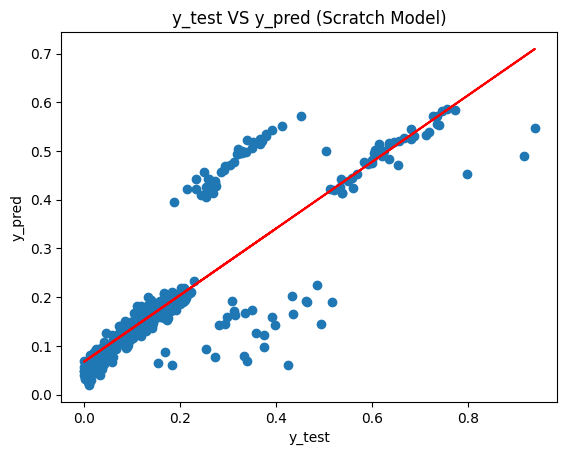

In [ ]:
a = y_test.values.ravel()
b = y_pred_scratch

plt.scatter(a, b)
m, c = np.polyfit(a, b, 1)
plt.plot(a, m * a + c, color='red')

plt.title("y_test VS y_pred (Scratch Model)")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()

How to Approach the Research Tasks :)

Guys, one important thing about how you should approach these tasks.

The links and videos provided are meant to be read/watched. Go through them, understand the concepts, and then write what you understood in your own words. You can also find your own resources — don't restrict yourself to the links we provide.

And please, don’t just GPT your way through the tasks. These are your foundational basics, so actually understand what you're doing. Try reading documentation, Stack Overflow discussions, technical articles, etc. These will become your best guides when you're learning ML independently.

The Research Task is compulsory and one of the most important parts of your learning, irrespective of what you do. Research is an engineer's way of learning — it's how you learn ML for what it actually is, rather than just learning how to write the code.

For the Research Task, research properly, understand what you find, and explain it in your own words. No implementation is required unless mentioned.

The best Research Task submission after every task will be featured on Synapse's LinkedIn with a tag, giving you an opportunity to connect with our alumni and seniors and grow your network.

So don't treat the Research Task as just another question to finish. Actually explore, understand, and learn from it :)

## Research Task: Underfitting & Overfitting

We’ve now built our first Linear Regression model. Before moving ahead, let’s understand an important problem that can affect any ML model: **Underfitting and Overfitting**.

### Resources

Read/watch the following:

* [SuperAnnotate — Overfitting & Underfitting](https://www.superannotate.com/blog/overfitting-and-underfitting-in-machine-learning) — simple theory and intuition
* [GreyAtom — Underfitting & Overfitting](https://medium.com/greyatom/what-is-underfitting-and-overfitting-in-machine-learning-and-how-to-deal-with-it-6803a989c76) — includes mathematical intuition
* [2-minute video](https://youtu.be/pptU3bpJojo?si=1uZ4yO_OQGkvEym-) — quick visual explanation

You can also find your **own resources** if you want to understand something better.

### Your Task

After going through the resources, write **what you understood in your own words**.

Make sure you can explain:

* What is underfitting?
* What is overfitting?
* What are **bias and variance**, and how are they related to underfitting and overfitting?
* How can you identify whether a model is underfitting or overfitting?
* Mention at least **one way to deal with each**.

You don't need to copy definitions from the resources. The goal is to see whether **you actually understand the concept and can explain it yourself**.

**No implementation is required.** Focus on understanding the concepts and explaining them clearly.

*Good Luck People :)*


Underfitting occurs when a model is too simple and fails to learn the important patterns in the data, resulting in poor performance on both training and testing data. It is associated with high bias. Overfitting occurs when a model learns the training data too specifically, including noise, so it performs very well on training data but poorly on unseen testing data. It is associated with high variance. Bias represents error due to overly simple assumptions, while variance represents the model's sensitivity to changes in the training data. The bias-variance trade-off is about finding a balance between the two so that the model generalizes well. Underfitting can be handled by increasing model complexity or adding relevant features, while overfitting can be handled using regularization, reducing model complexity, adding more training data, or cross-validation.

Underfitting can be reduced by adding relevant features to the model. An underfitted model is too simple and may not have enough information to capture the important patterns in the data. By including relevant features, the model gets more useful information and can learn more complex relationships between the input and output. However, only meaningful features should be added because irrelevant features can increase model complexity and may lead to overfitting.

Overfitting can be reduced using regularization. Regularization adds a penalty term to the loss function to discourage the model from assigning unnecessarily large weights to features. For example, Lasso uses L1 regularization, where the sum of absolute coefficients is added as a penalty. This reduces model complexity and can make some coefficients zero, helping the model generalize better to unseen data.

Linear Regression is a supervised learning algorithm used to predict continuous numerical values. It finds the best-fitting line between input and output variables. In simple linear regression, this relationship is represented by \(y=mx+c\), where \(m\) is the slope and \(c\) is the intercept. The model learns these parameters from training data and uses them to make predictions. The difference between actual and predicted values is called the residual or error. MSE measures the average squared error of the predictions, and the objective is to minimize this loss. The best-fit line can be obtained using the least squares method, while gradient descent is one optimization method that can be used to update the parameters and minimize the loss.When multiple input features are used, the method is called multiple linear regression.

End of Task

©DJS Synapse 2026 - 2027